# Midterm Project

For this project we will use the [Gaia DR3 data release](https://gea.esac.esa.int/archive/) to explore the solar neighborhood. This is the same selection of data we've explored recently, which can be pulled from the Gaia data archive with the following query:

```sql
SELECT TOP 300000 phot_g_mean_mag+5*log10(parallax)-10 AS mg, bp_rp, parallax FROM gaiadr3.gaia_source
WHERE parallax_over_error > 10
AND parallax > 10
AND phot_g_mean_flux_over_error>50
AND phot_rp_mean_flux_over_error>20
AND phot_bp_mean_flux_over_error>20
AND phot_bp_rp_excess_factor < 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
AND phot_bp_rp_excess_factor > 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
AND visibility_periods_used>8
AND astrometric_chi2_al/(astrometric_n_good_obs_al-5)<1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))
```

The data is also in the `data/` directory of this repository.

Using a subset of this data, we're going to focus on constructing models and inferring the parameters of those models using `NumPyro`.

## Data Down-Selection

To avoid lengthy run times we'll focus on only the nearby data.  Select out the objects with parallax > 40 milliarcseconds.


# Part I

For this part we'll remove (crudely) the white dwarf population (the dim secondary population of stars).  To do this we'll use a simple linear boundary to divide the population:

```python
x1, y1 = 0, 8
x2, y2 = 3, 16.5
m_div = (y2 - y1)/(x2 - x1)
b_div = y1 - m_div * x1
```

where we'll be focusing on the objects with $M_G < m_\mathrm{div} (BP-RP) + b_\mathrm{div}$.

1. Construct a `NumPyro` model that models the population as a line, assuming $M_G$ to be distributed normally about this line with a standard deviation to be inferred from the data.  Perform an MCMC.

    A. Discuss the differences between the prior distributions you choose for your model parameters and the marginal (i.e., one-dimensional) posterior distributions estimated with your MCMC.  Did you choose suitably uninformed priors?

    B. Plot the models corresponding to 50 randomly chosen posterior samples from your MCMC.  Discuss the quality of the fit, and in particular the role that the standard deviation parameter is playing in this fit.

2. Construct a new model that models the relation between $(BP-RP)$ and $M_G$ quadratically.  Carefully choose priors; be sure to explore choices for locations and scales that are appropriate for the new parameters.  Run an MCMC.

    A. Discuss the differences between the prior distributions you choose for your model parameters and the marginal (i.e., one-dimensional) posterior distributions estimated with your MCMC.  Did you choose suitably uninformed priors?

    B. Plot the model corresponding to 50 randomly chosen posterior samples from your MCMC.  Discuss the quality of the fit.

    C. **Graduate students:** Use your posterior estimates to predict the distribution we would expect for $M_G$ values of main sequence stars with color $(BP-RP) = 6$.

3. **Graduate students:** Explore higher order polynomials a bit.  How does the (qualitative) quality of the fit behave?

# Imports and Data Setup

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
from jax import random
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro
import arviz as az
from numpyro import infer
numpyro.set_host_device_count(2)

In [39]:
file_path='../../hub_data_share/gaiadr3_solar_neighborhood.csv'
try:
    # Assuming data is in a structured format like CSV or similar
    Data = pd.read_csv(file_path, delimiter=',')
    # Process the DataFrame
    print(Data)

except FileNotFoundError:
    print(f"File '{file_path}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")
type(Data)

               mg     bp_rp    parallax
0       10.390250  2.731872   10.000008
1        8.608481  2.025819   10.000029
2        4.267759  0.880858   10.000032
3       10.506658  2.649735   10.000066
4       12.077941  2.940875   10.000111
...           ...       ...         ...
227624  11.758283  2.834036  336.026602
227625   9.521769  2.215609  392.752945
227626  14.129570  4.184836  415.179416
227627  11.883816  2.833697  546.975940
227628  13.411743  3.804580  768.066539

[227629 rows x 3 columns]


pandas.core.frame.DataFrame

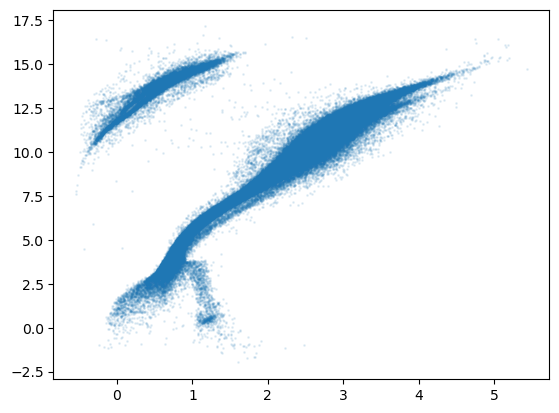

In [40]:
plt.scatter(Data['bp_rp'],Data['mg'],alpha=.1,s=1);

In [41]:
nearby=Data.parallax>40
Data=Data[nearby]

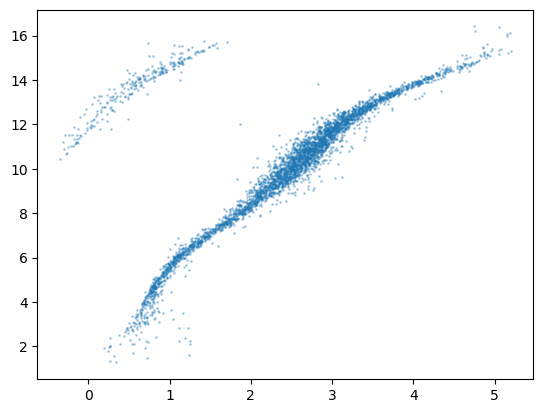

In [42]:
plt.scatter(Data['bp_rp'],Data['mg'],alpha=.3,s=1);

# Part I

Text(0.5, 0, '(Bp-Rp)')

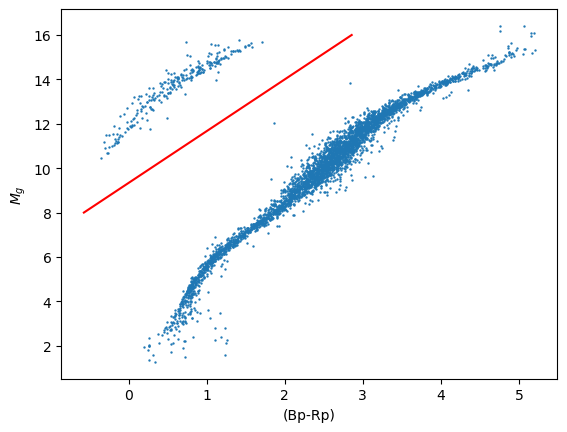

In [47]:
X=np.linspace(8, 16, 100)
plt.scatter(Data['bp_rp'],Data['mg'],s=.5)
plt.plot(3/7*X-4,X, color='red')
plt.ylabel(r'$M_g$')
plt.xlabel('(Bp-Rp)')

In [48]:
SortedDataIndex=3/7*Data['mg']-Data['bp_rp']<4
data=Data[SortedDataIndex]

Text(0.5, 0, 'bp_rp')

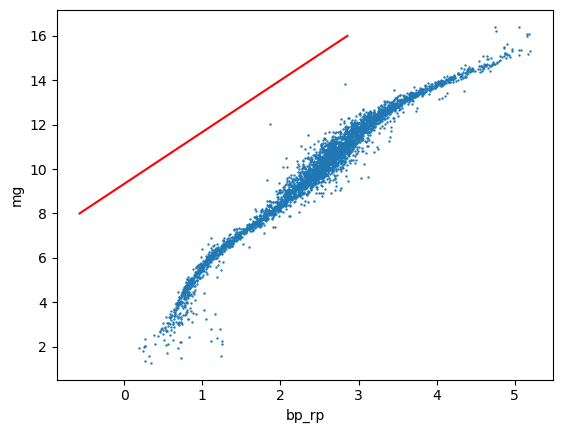

In [49]:
X=np.linspace(8, 16, 100)
plt.scatter(data['bp_rp'],data['mg'],s=.5)
plt.plot(3/7*X-4,X, color='red')
plt.ylabel('mg')
plt.xlabel('bp_rp')

In [50]:
x=jnp.array(data['bp_rp']) #credit to Hannah for a hint to use jnp.array
y=jnp.array(data['mg'])

## 1) Linear Model MCMC

In [51]:
#From co2
def linear_model(x=None, y=None,σ=None):
    # priors
    m = numpyro.sample('m', dist.Uniform(0,10))#slope looks to be about 3
    b = numpyro.sample('b', dist.Uniform(-10,10)) #I'm not sure if I should be allowing for negative y-intercepts
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=100))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", m * x + b)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [52]:
#from co2
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      2.58      0.03      2.58      2.54      2.62    841.76      1.01
         m      2.94      0.01      2.94      2.92      2.95    887.76      1.01
   scatter      0.57      0.01      0.57      0.56      0.58    896.18      1.00

Number of divergences: 0


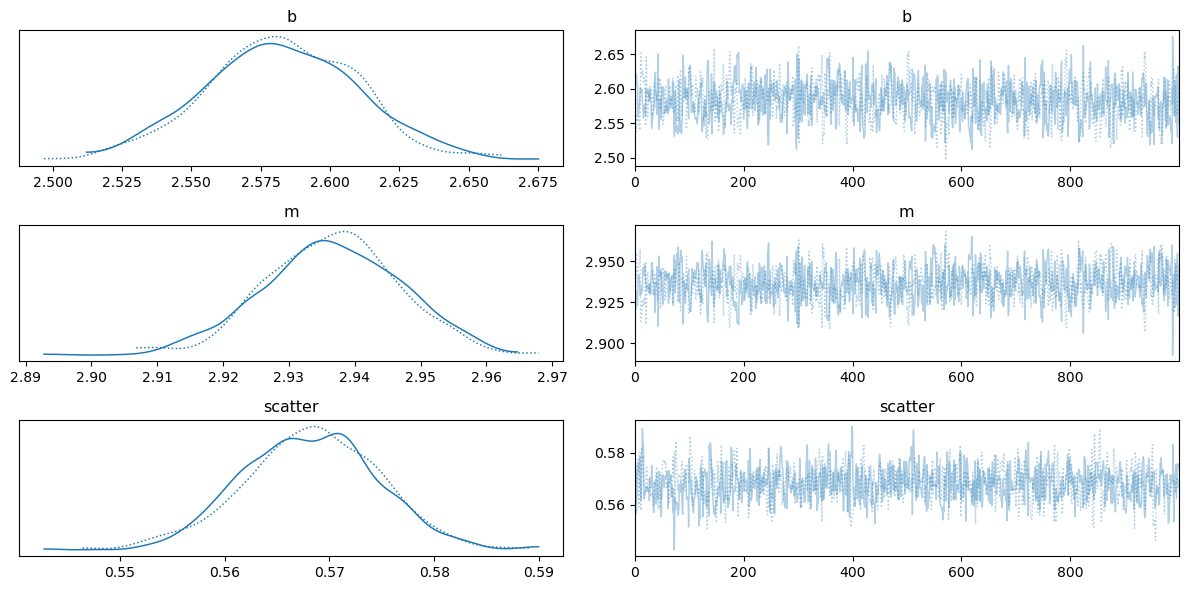

In [12]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

I used uniform distributions for the parameters on my priors, except for $\sigma$ which was a half-normal. This seemed to work very well. I got vaguely normal distrtributions with flat caterpillar shapes and the two MCMC runs lined up well. This indicates that the run converged well. I had uniform priors with wide ranges so the approximately normal shape of the posterior can't just be an artifact of the prior, and I let the MCMC explore a wide space of feasible parameter values.

array([[<Axes: ylabel='b'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='m'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='b', ylabel='scatter'>, <Axes: xlabel='m'>,
        <Axes: xlabel='scatter'>]], dtype=object)

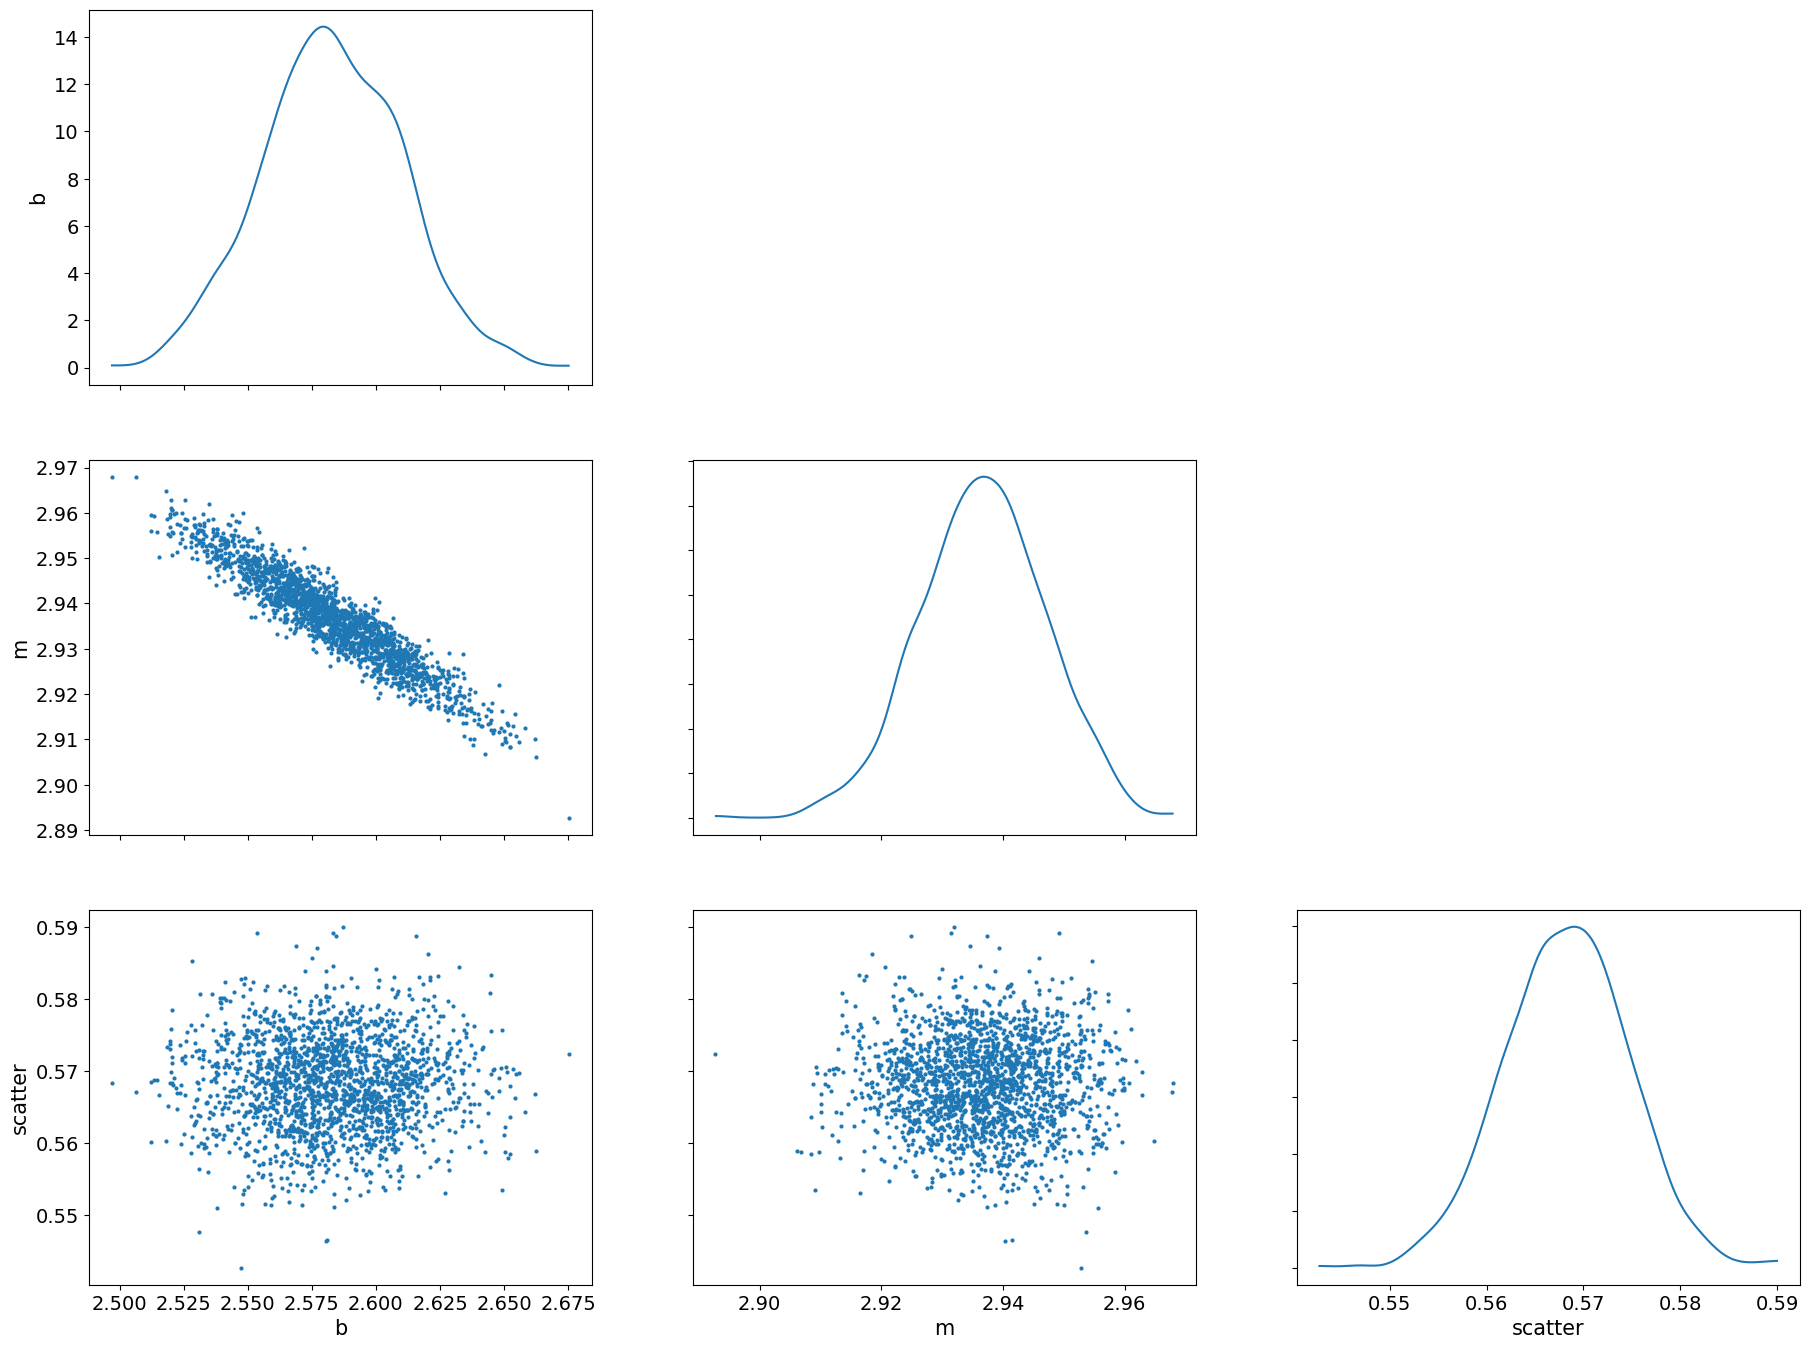

In [13]:
az.plot_pair(mcmc,var_names=['~μ'], marginals=True)
# marginal=True shows posteriors

In [54]:
samples = mcmc.get_samples()

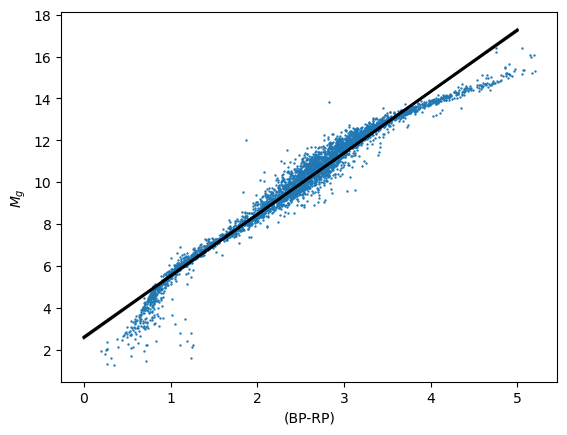

In [59]:
X = jnp.linspace(0, 5, 100)
counter=0
plt.scatter(x,y,s=.5)
for i in random.choice(rng_key, num_samples, (50,)):
    counter+=1
    mu = samples['m'][i] * X + samples['b'][i]
    plt.plot(X, mu, color='k', alpha=0.1);
plt.ylabel(r'$M_g$')
plt.xlabel('(BP-RP)');

In [56]:
counter

50

### Discussion

## 2) Quadratic Model MCMC

In [16]:
#from co2
def quadratic_model(x=None, y=None,σ=None):
    # priors
    a = numpyro.sample('a', dist.Uniform(-10,10))#I'm allowing a much wider range than I think I need to ensure I sample the whole space
    b = numpyro.sample('b', dist.Uniform(-10,10))
    c = numpyro.sample('c', dist.Uniform(-10,10)) 
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=10))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", a * x**2 + b*x+c)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [17]:
#from co2
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(quadratic_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.30      0.01     -0.30     -0.31     -0.29    532.32      1.00
         b      4.40      0.03      4.40      4.35      4.45    464.07      1.00
         c      1.06      0.04      1.06      1.00      1.13    449.12      1.00
   scatter      0.45      0.00      0.45      0.44      0.46    633.32      1.00

Number of divergences: 0


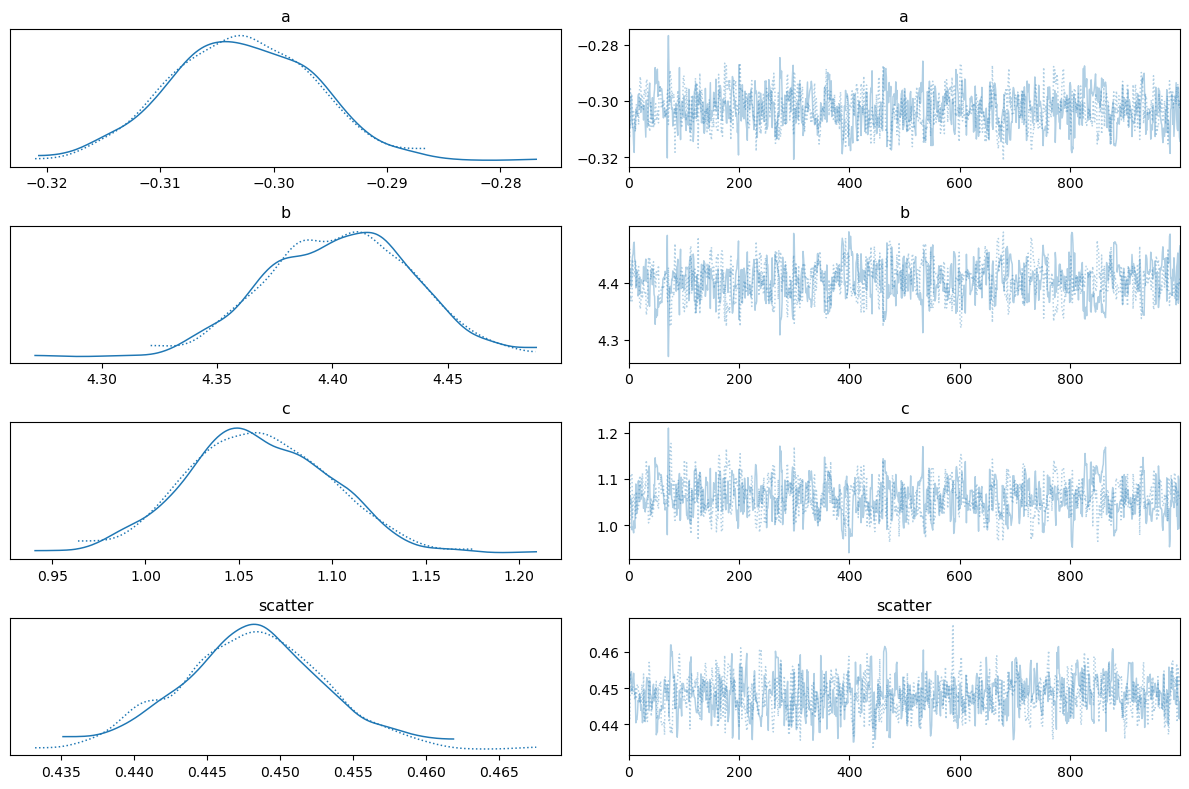

In [18]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

array([[<Axes: ylabel='a'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='b'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='c'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='a', ylabel='scatter'>, <Axes: xlabel='b'>,
        <Axes: xlabel='c'>, <Axes: xlabel='scatter'>]], dtype=object)

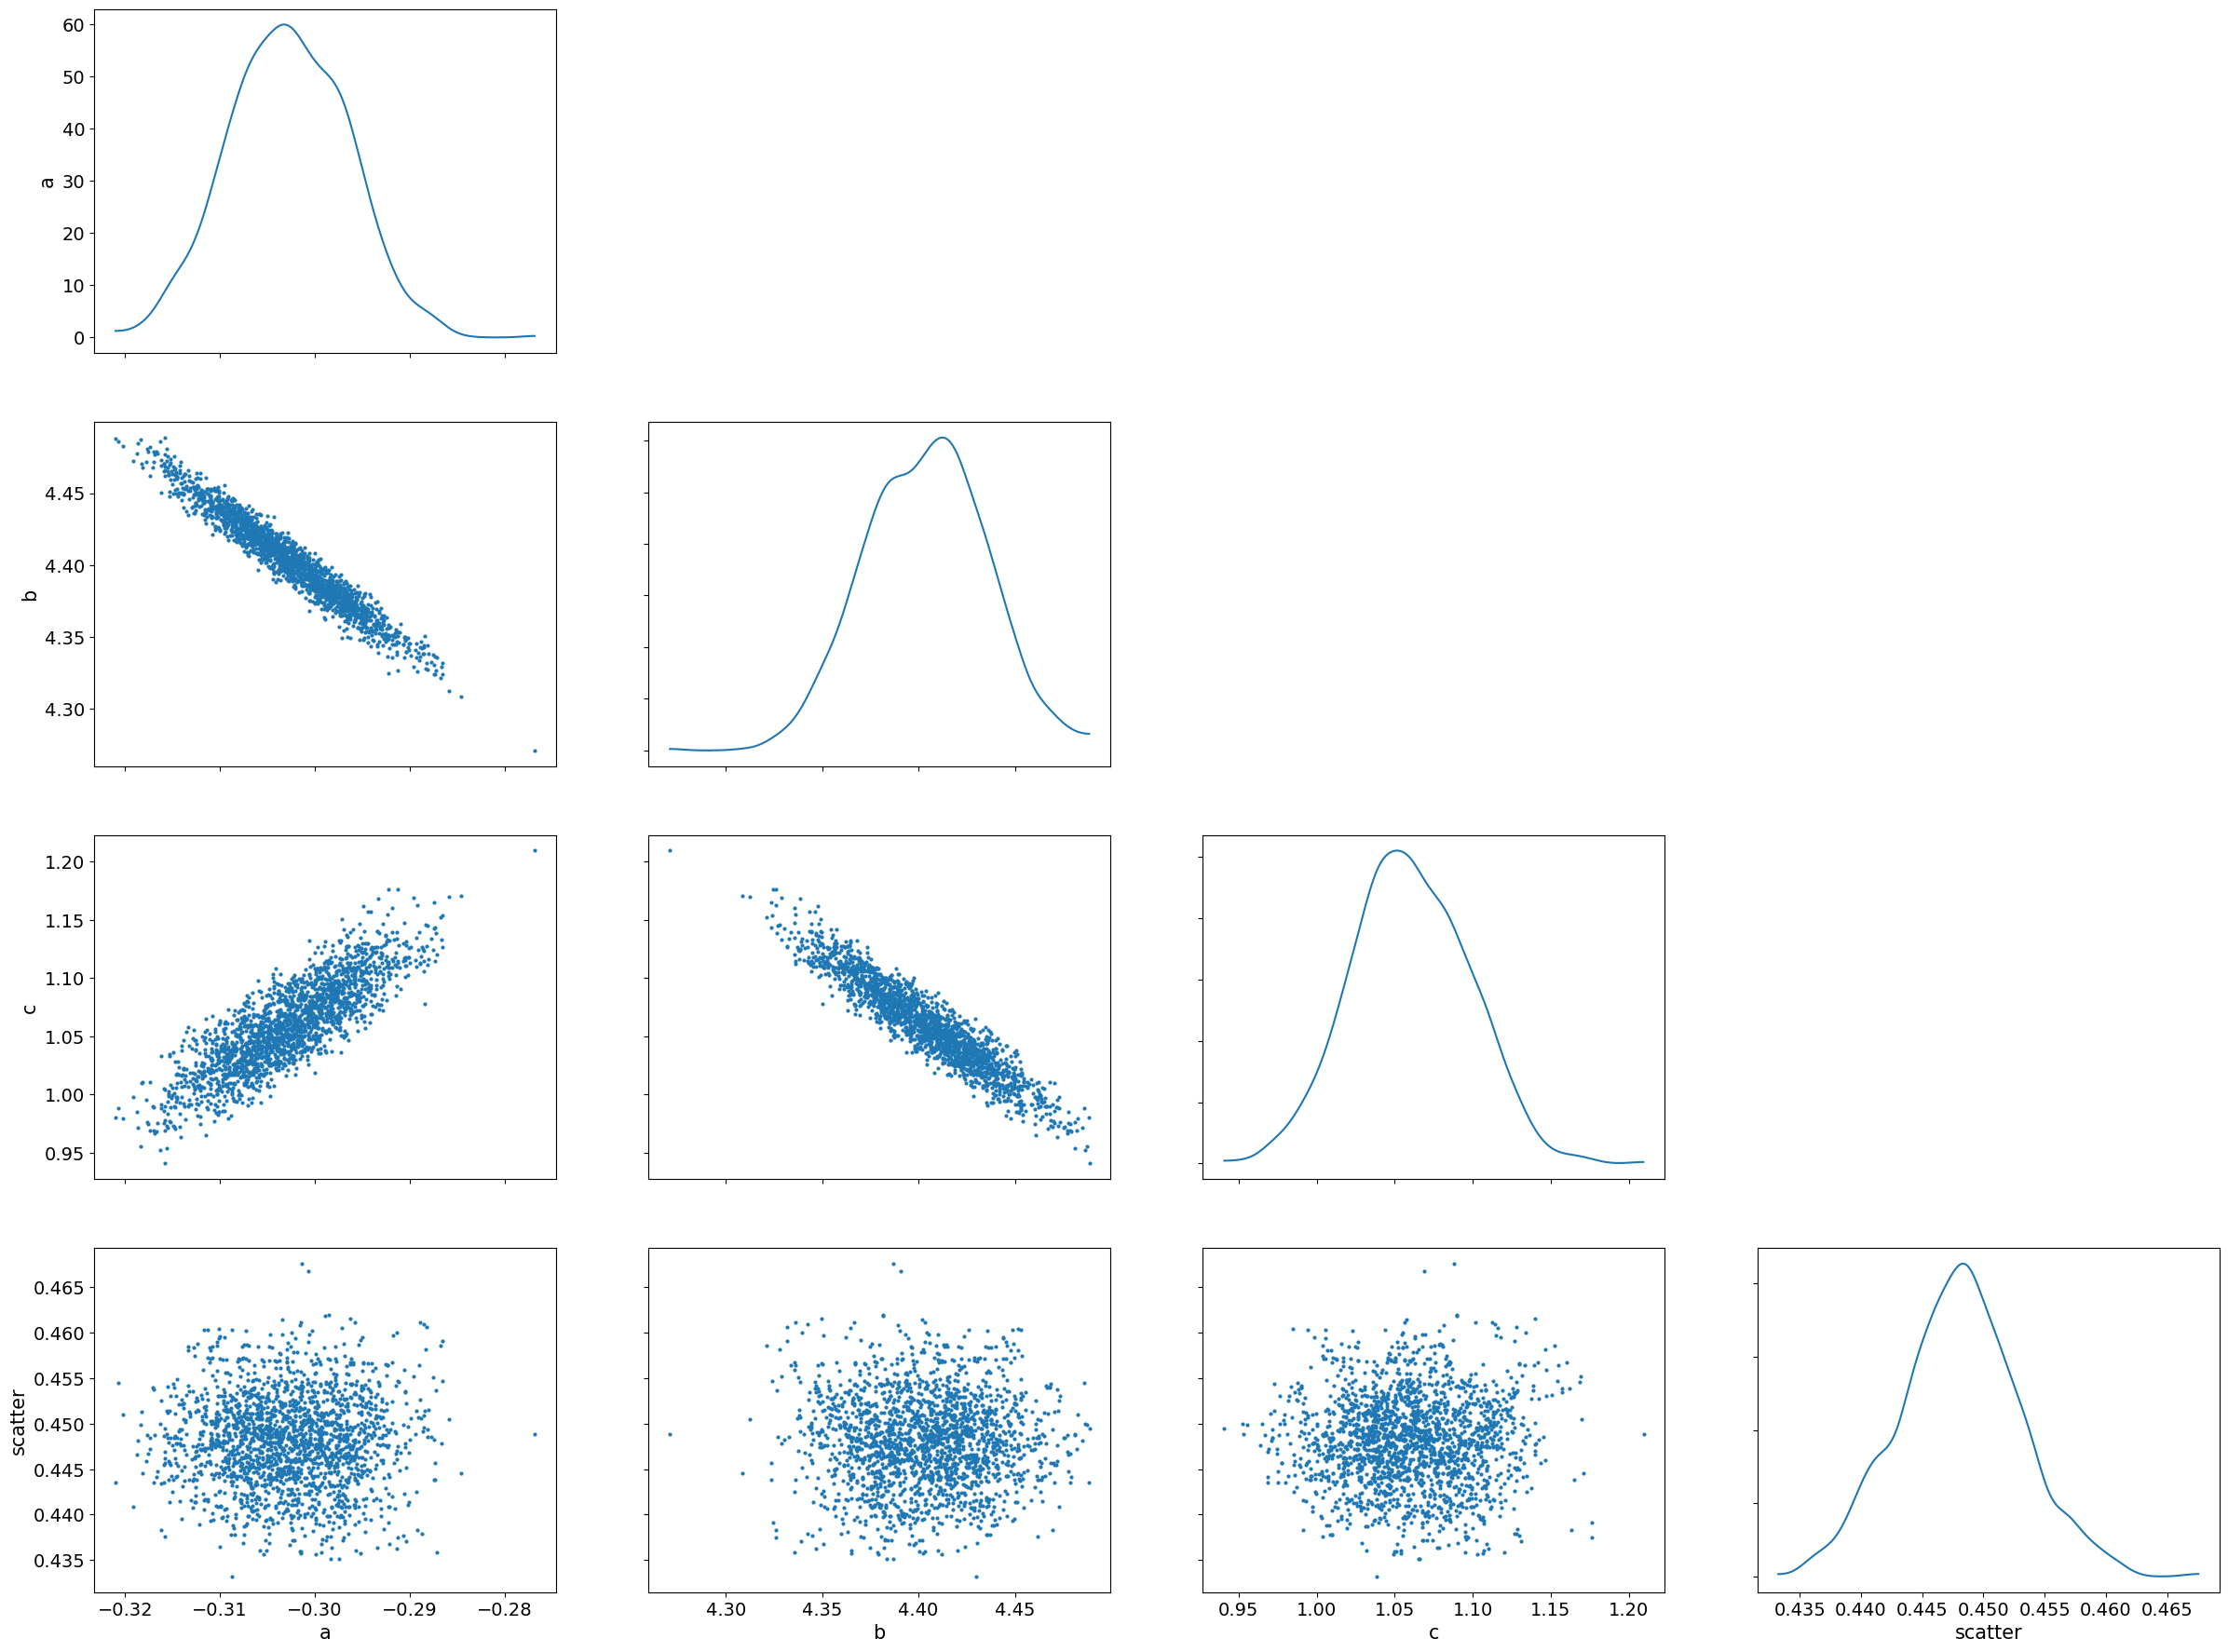

In [19]:
az.plot_pair(mcmc,var_names=['~μ'], marginals=True)
# marginal=True shows posteriors

In [20]:
samples = mcmc.get_samples()

Text(0.5, 0, 'bp_rp')

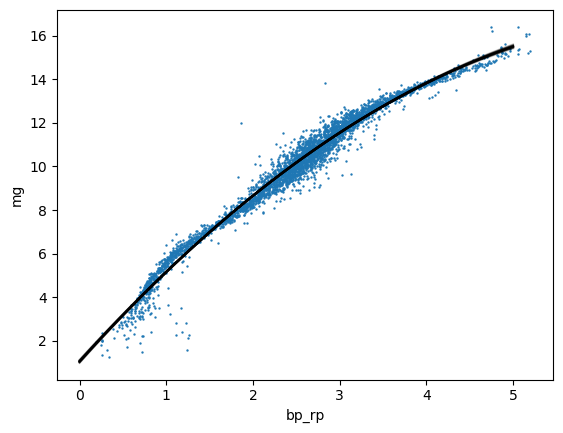

In [21]:
plt.scatter(x,y,s=.5)
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * X**2 + samples['b'][i]*X+samples['c'][i]
    plt.plot(X, mu, color='k', alpha=0.1);
plt.ylabel('mg')
plt.xlabel('bp_rp')

In [22]:
#from outliers

post_pred_samples = infer.Predictive(quadratic_model, samples)(
    random.PRNGKey(1), x=np.array([0.6]),y=None
)
post_pred_y = post_pred_samples["y"]
post_pred_y.shape


(2000, 1)

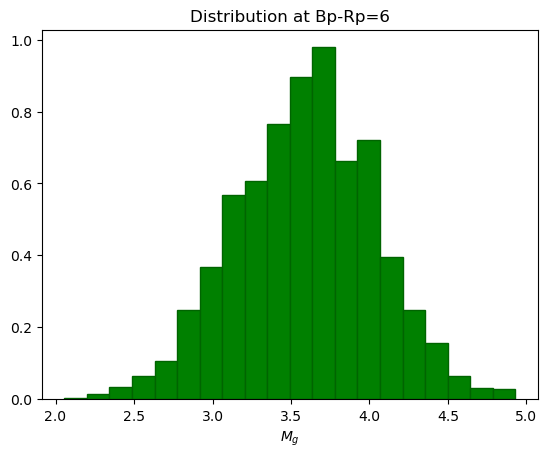

In [23]:
plt.hist(post_pred_y,bins=20,density=True,facecolor='green',edgecolor='darkgreen'); #distribution for bprp=6
plt.title('Distribution at Bp-Rp=6')
plt.xlabel(r'$M_g$');

## 3) Higher Order Polynomials

In [19]:
#from co2
def third_order_model(x=None, y=None,σ=None):
    # priors
    a = numpyro.sample('a', dist.Uniform(-10,10))#I'm allowing a much wider range than I think I need to ensure I sample the whole space
    b = numpyro.sample('b', dist.Uniform(-10,10))
    c = numpyro.sample('c', dist.Uniform(-10,10)) 
    d = numpyro.sample('d', dist.Uniform(-10,10)) 
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=10))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", a * x**3 + b*x**2 + c*x + d)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [34]:
#from co2
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(third_order_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.02      0.01     -0.02     -0.03     -0.01    401.74      1.00
         b     -0.17      0.04     -0.17     -0.25     -0.11    377.02      1.00
         c      4.10      0.10      4.10      3.93      4.27    366.87      1.00
         d      1.24      0.07      1.25      1.13      1.36    384.86      1.01
   scatter      0.45      0.01      0.45      0.44      0.46    594.17      1.00

Number of divergences: 0


In [36]:
samples = mcmc.get_samples()

Text(0.5, 0, 'bp_rp')

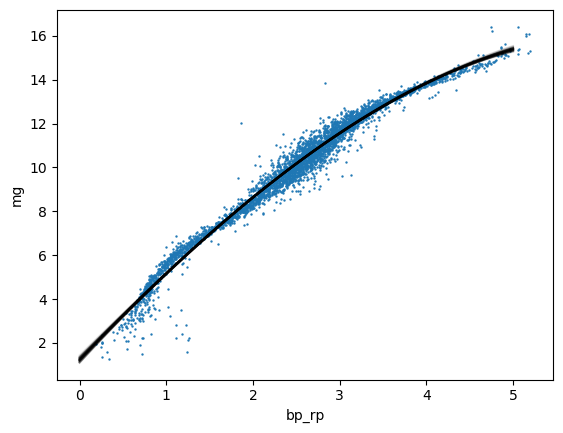

In [37]:
X=np.linspace(0, 5, 100)
plt.scatter(x,y,s=.5)
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * X**3 + samples['b'][i]*X**2+samples['c'][i]*X+samples['d'][i]
    plt.plot(X, mu, color='k', alpha=0.1);
plt.ylabel('mg')
plt.xlabel('bp_rp')

We can see that the third order coefficient is smaller even than the second, meaning a third order term has little impact on the model. We'll try fourth order too:

In [72]:
#from co2
def fourth_order_model(x=None, y=None,σ=None):
    # priors
    a = numpyro.sample('a', dist.Uniform(-10,10))#I'm allowing a much wider range than I think I need to ensure I sample the whole space
    b = numpyro.sample('b', dist.Uniform(-10,10))
    c = numpyro.sample('c', dist.Uniform(-10,10)) 
    d = numpyro.sample('d', dist.Uniform(-10,10)) 
    e = numpyro.sample('e', dist.Uniform(-10,10)) 
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=10))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", a * x**4 + b*x**3 + c*x**2 + d*x +e)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [73]:
#from co2
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(fourth_order_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.04      0.00     -0.04     -0.05     -0.04    246.35      1.01
         b      0.45      0.04      0.45      0.37      0.52    233.26      1.01
         c     -1.89      0.16     -1.88     -2.15     -1.61    222.10      1.01
         d      6.56      0.25      6.55      6.18      7.00    215.69      1.01
         e      0.15      0.12      0.15     -0.05      0.35    222.59      1.01
   scatter      0.44      0.01      0.44      0.43      0.45    308.03      1.00

Number of divergences: 0


In [74]:
samples = mcmc.get_samples()

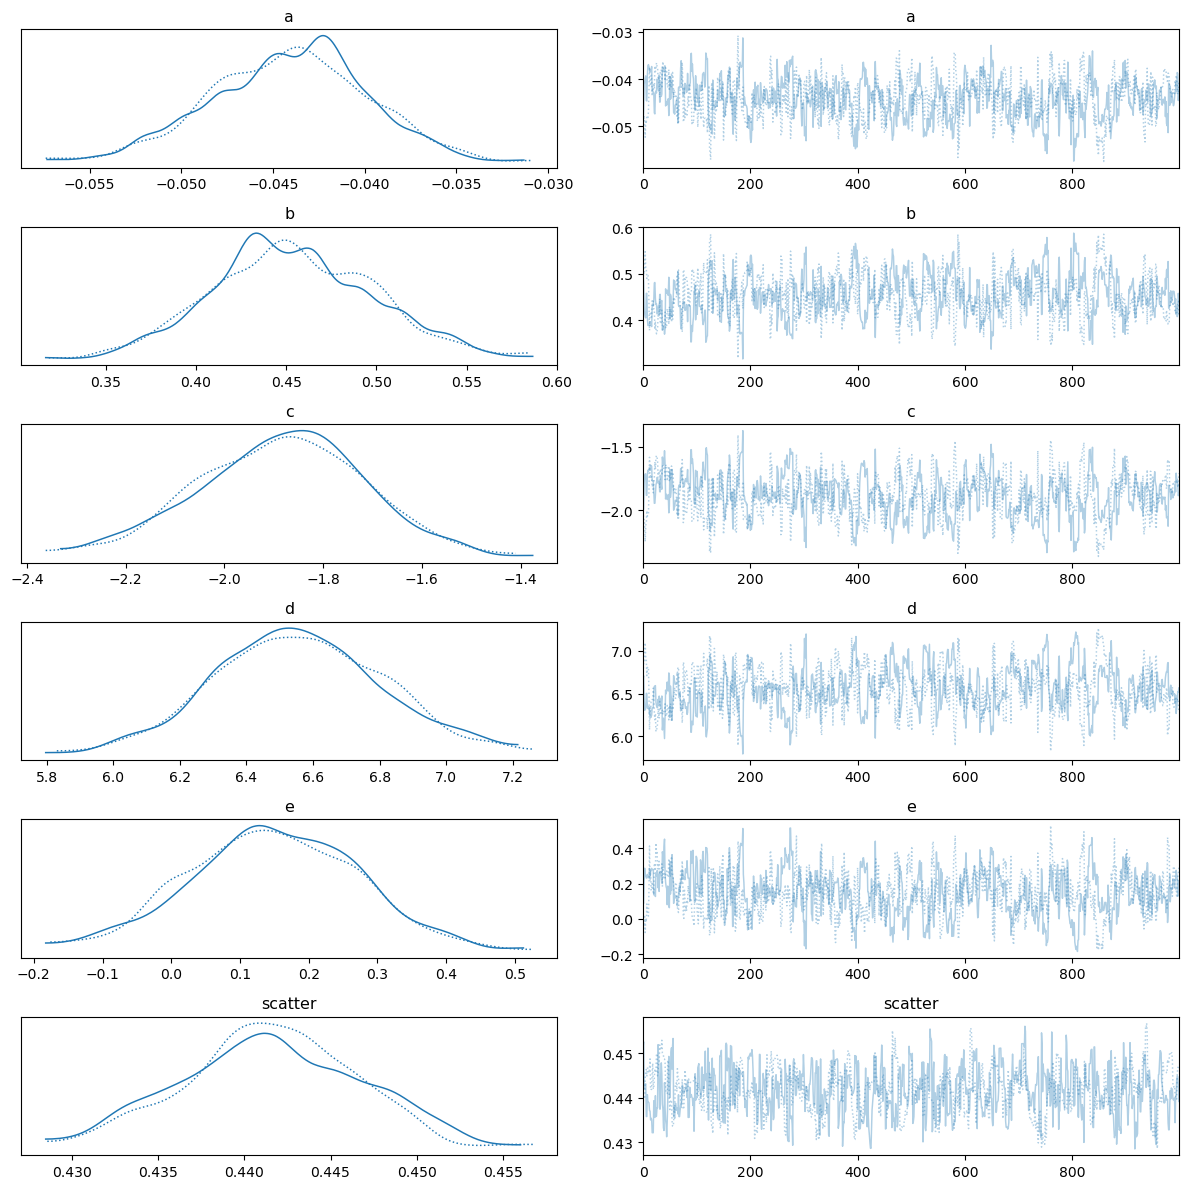

In [75]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

Text(0.5, 0, 'bp_rp')

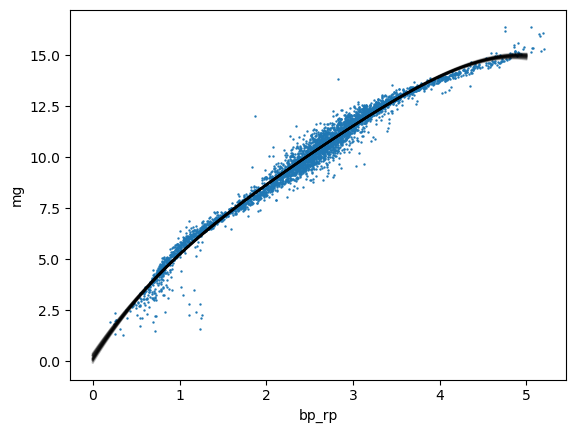

In [77]:
X=np.linspace(0, 5, 100)
plt.scatter(x,y,s=.5)
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * X**4 + samples['b'][i]*X**3+samples['c'][i]*X**2+samples['d'][i]*X+samples['e'][i]
    plt.plot(X, mu, color='k', alpha=0.1);
plt.ylabel('mg')
plt.xlabel('bp_rp')

It looks like the model does get slightly better at predicting the shape at each end of the graph, but it's a very slight change

In [61]:
#from co2
def fifth_order_model(x=None, y=None,σ=None):
    # priors
    a = numpyro.sample('a', dist.Uniform(-10,10))#I'm allowing a much wider range than I think I need to ensure I sample the whole space
    b = numpyro.sample('b', dist.Uniform(-10,10))
    c = numpyro.sample('c', dist.Uniform(-10,10)) 
    d = numpyro.sample('d', dist.Uniform(-10,10)) 
    e = numpyro.sample('e', dist.Uniform(-10,10)) 
    f = numpyro.sample('f', dist.Uniform(-10,10)) 
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=10))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", a * x**5 + b*x**4 + c*x**3 + d*x**2 +e*x+f)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [66]:
#from co2
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(fifth_order_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.09      0.11     -0.09     -0.20      0.03      1.00     81.57
         b      1.02      1.39      1.09     -0.39      2.41       nan     79.03
         c     -1.08      3.04     -1.41     -4.11      2.10      1.00     36.41
         d     -6.28      1.29     -6.58     -7.54     -4.68      1.03      7.06
         e      2.49      6.91      1.68     -4.41      9.72       nan     36.98
         f      2.94      3.64      3.25     -0.82      6.57      1.00     49.90
   scatter      0.83      0.40      0.84      0.43      1.23       nan    126.23

Number of divergences: 0


/home/.hub_local/python_libs/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/.hub_local/python_libs/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/.hub_local/python_libs/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/.hub_local/python_libs/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/.hub_local

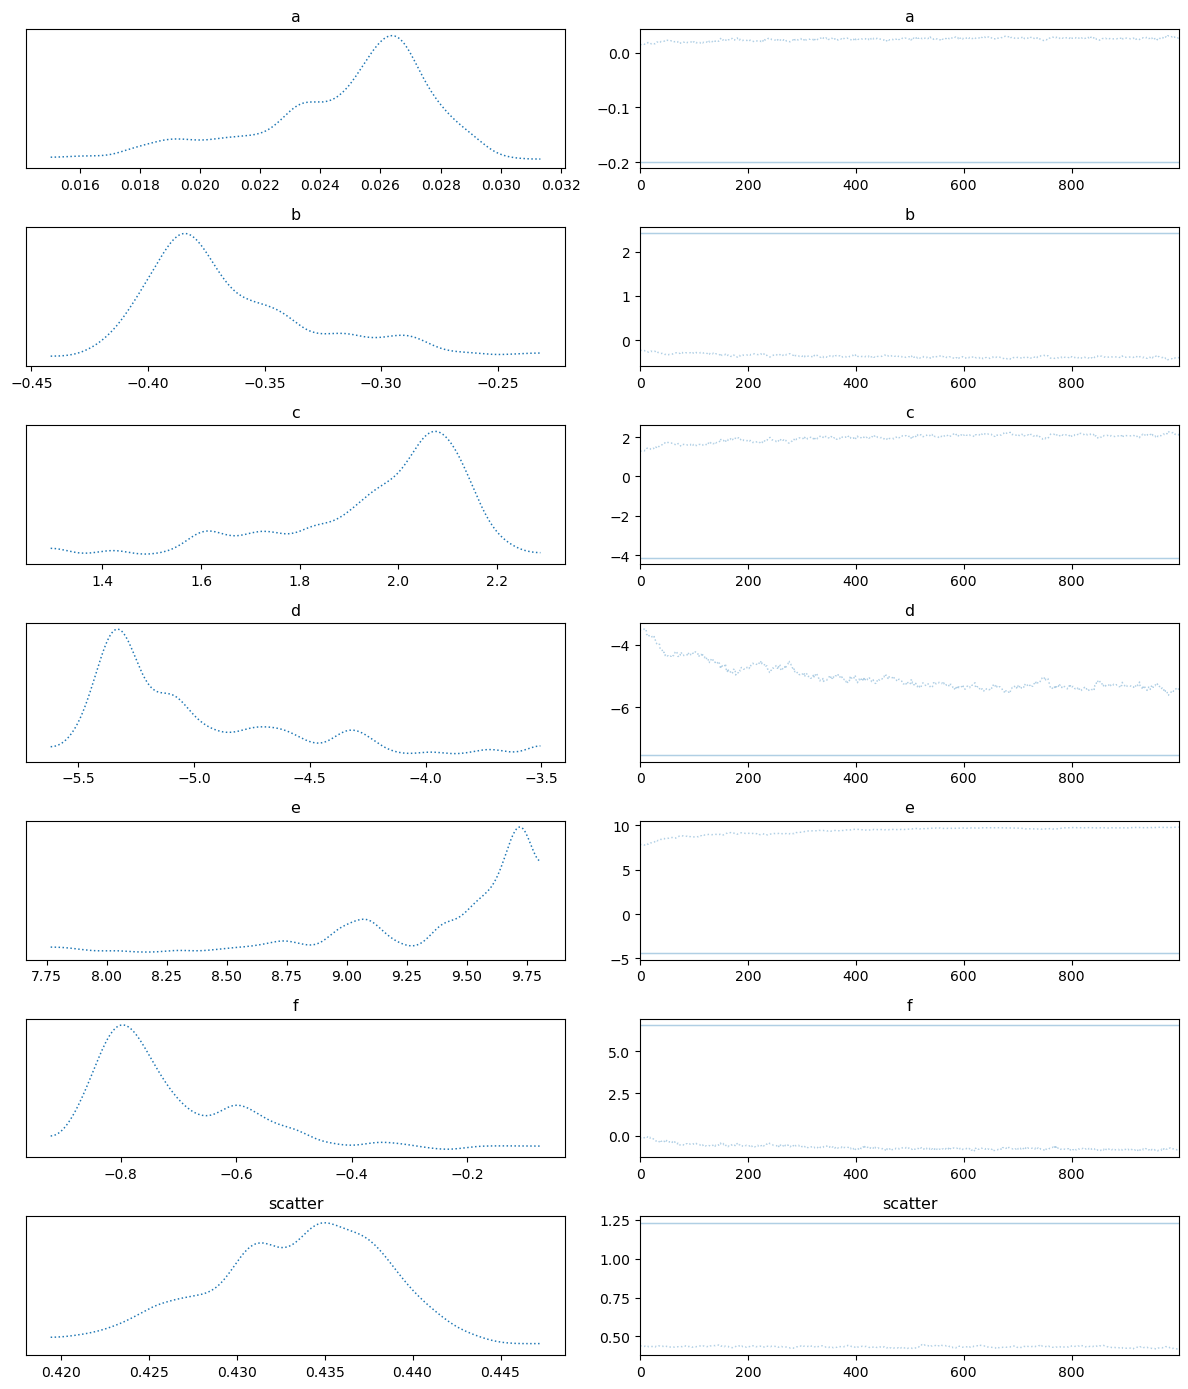

In [71]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

In [69]:
samples = mcmc.get_samples()

Text(0.5, 0, 'bp_rp')

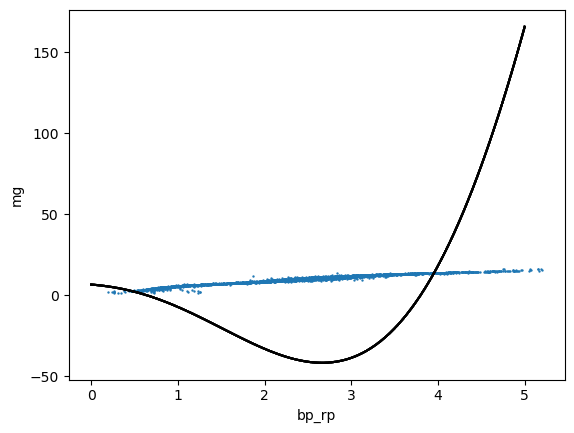

In [70]:
X=np.linspace(0, 5, 100)
plt.scatter(x,y,s=.5)
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * X**5 + samples['b'][i]*X**4+samples['c'][i]*X**3+samples['d'][i]*X**2+samples['e'][i]*X+samples['f'][i]
    plt.plot(X, mu, color='k', alpha=0.1);
plt.ylabel('mg')
plt.xlabel('bp_rp')

array([[<Axes: ylabel='a'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='b'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='c'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='e'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='a', ylabel='scatter'>, <Axes: xlabel='b'>,
        <Axes: xlabel='c'>, <Axes: xlabel='d'>, <Axes: xlabel='e'>,
        <Axes: xlabel='scatter'>]], dtype=object)

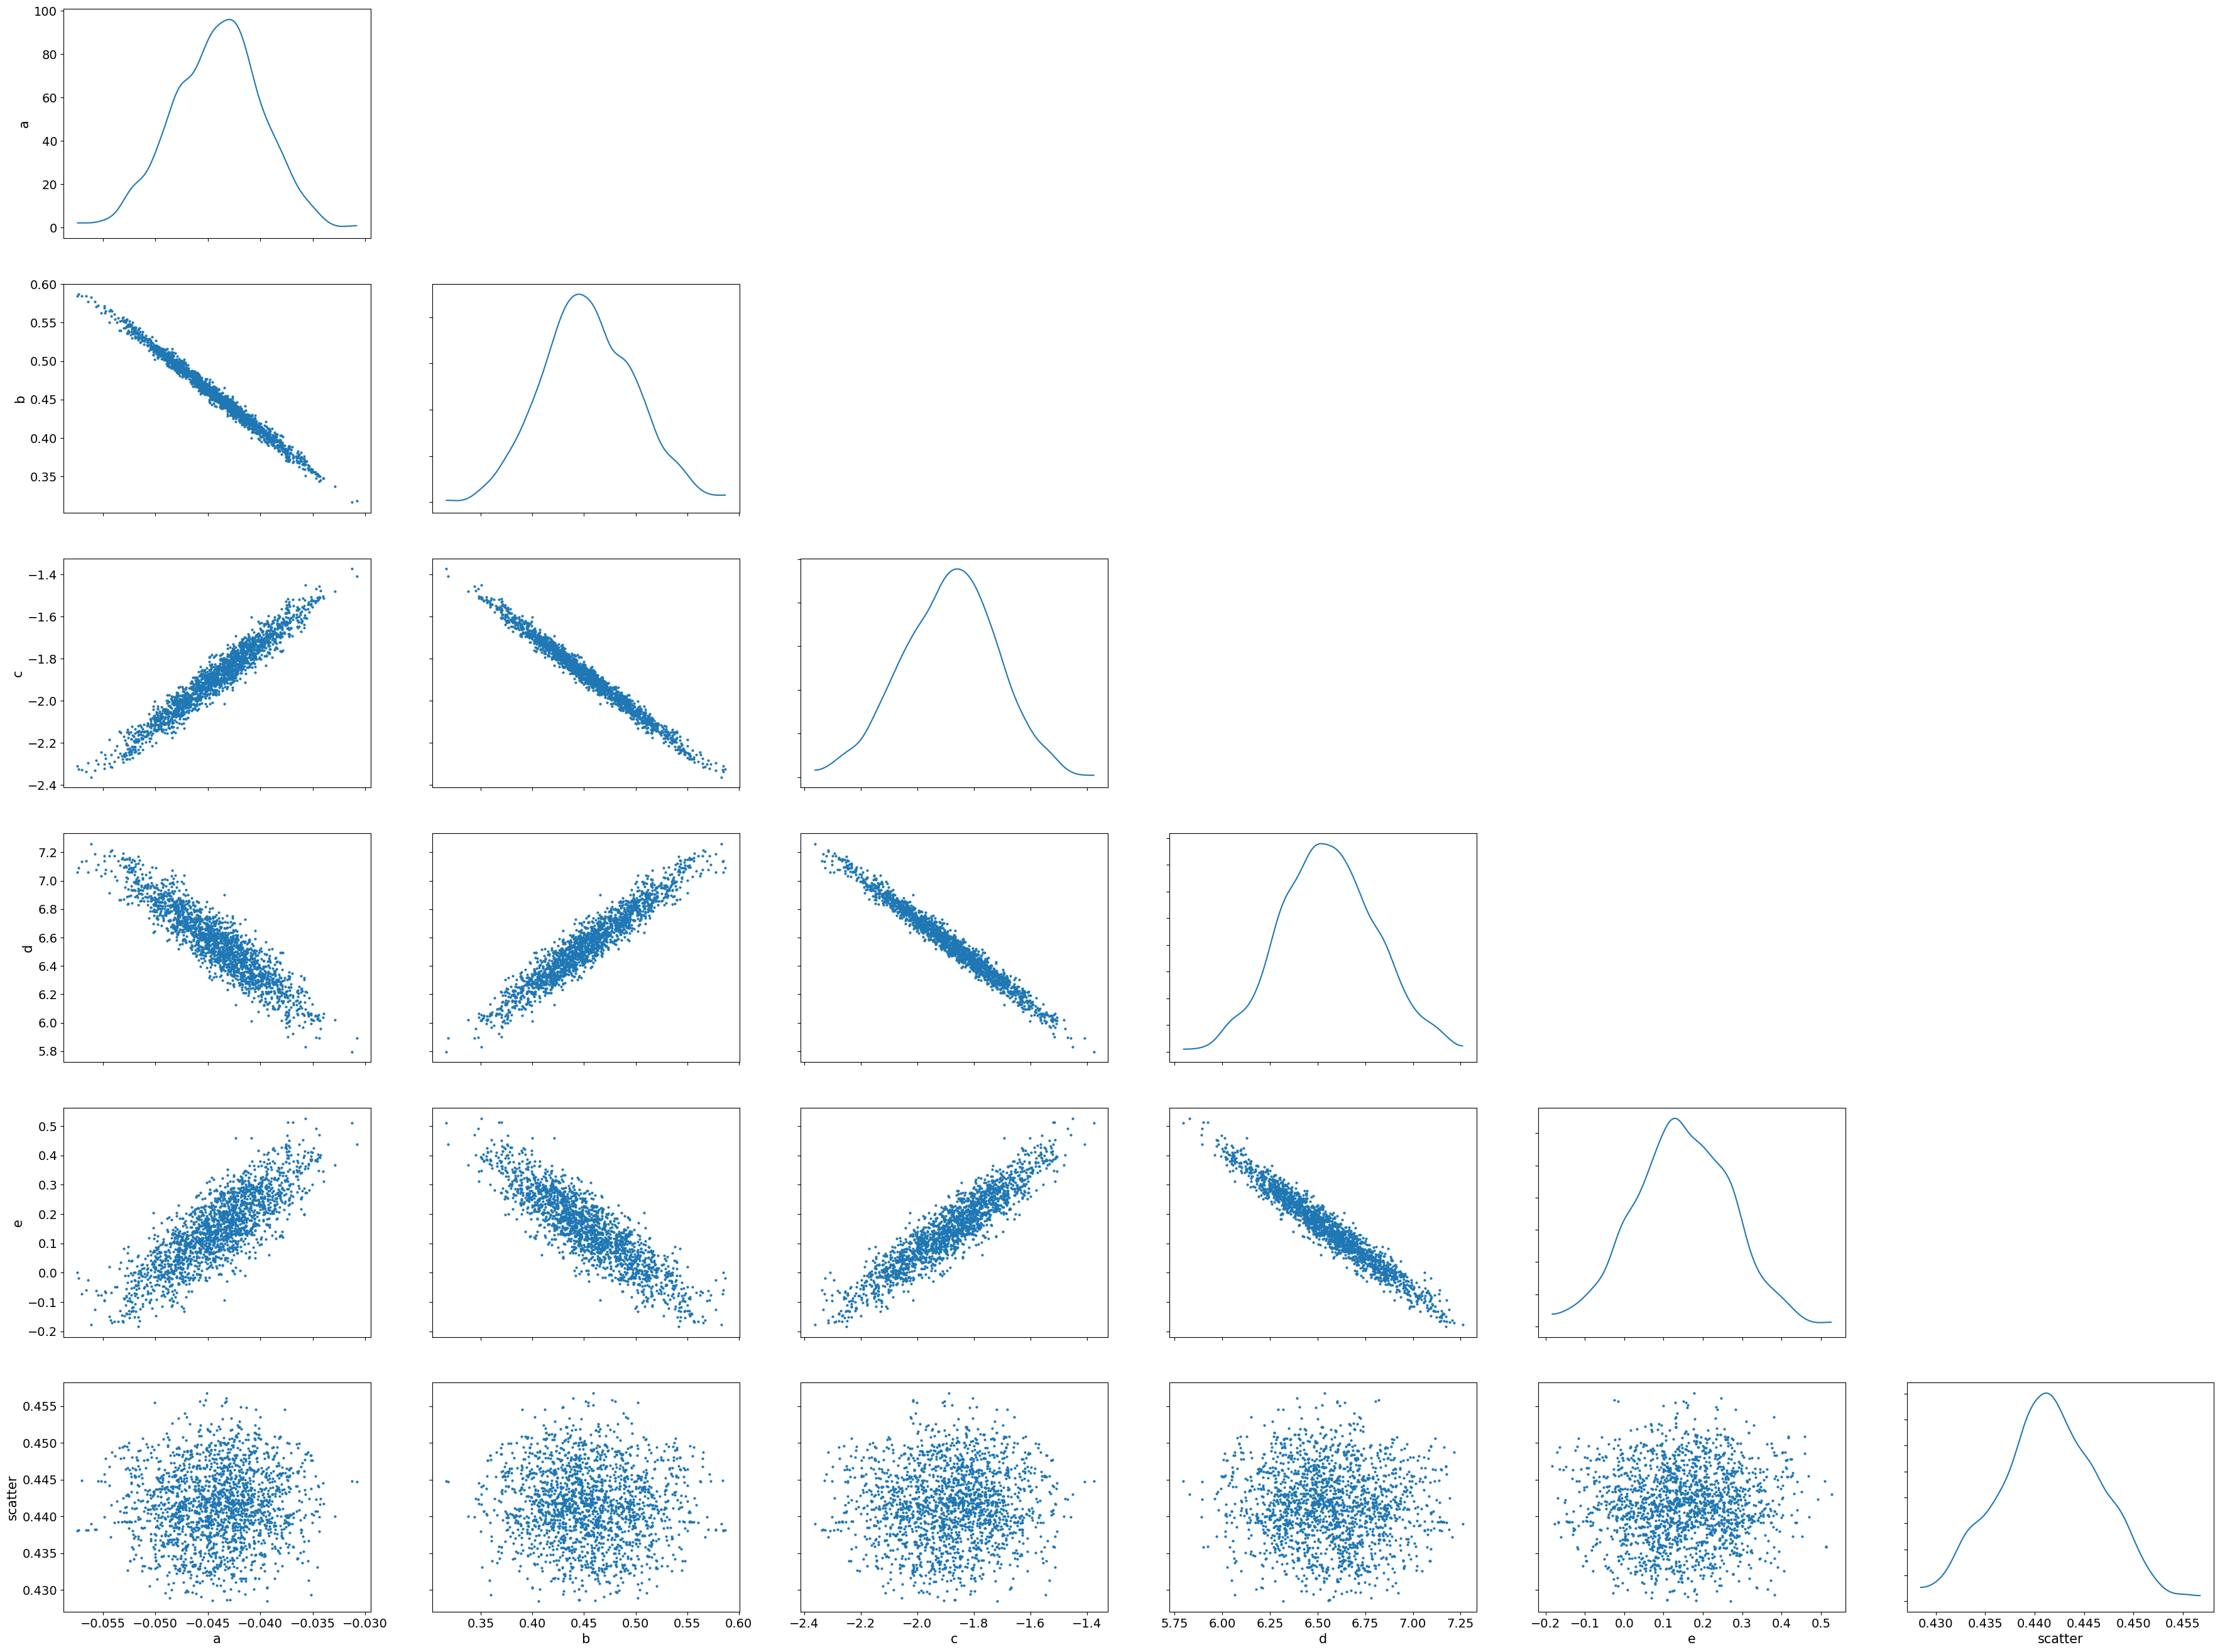

In [65]:
az.plot_pair(mcmc,var_names=['~μ'], marginals=True)

# Part II

Now let's bring the white dwarfs back into the mix, focusing on all the objects with parallax > 40 milliarcseconds.

1. Construct a mixture model with `NumPyro` that simultaneously describes the main sequence stars and white dwarfs, each described by a linear relationship with its own slope, y-intercept, and scatter of observations about it.

    **Tips:**
    1. Recall our outlier model we built, which outlines the machinery for building a mixture model that allows for our data to be described by more than one distribution.
    1. Our model will now be composed of two lines.  If we impose the same priors for the parameters of each line, then the two lines will be degenerate and sampling gets unnecessarily tricky.  There are many ways we could avoid this degeneracy, but for now I suggest imposing unique priors on the y-intercepts.  I also recommend a relatively narrow prior on the slopes of the lines to get the model from trying crazy solutions:
        ```python
        m_ms = numpyro.sample('m_ms', dist.Uniform(2, 5))
        b_ms = numpyro.sample('b_ms', dist.Uniform(0, 5))

        m_wd = numpyro.sample('m_wd', dist.Uniform(2, 5))
        b_wd = numpyro.sample('b_wd', dist.Uniform(10, 15))
        ```
2. Plot the two lines for each of 50 randomly chosen posterior samples from your MCMC.  Discuss the quality of the fits, and in particular the constraints.  Is the model able to identify the two populations?

3. **Graduate students:**
    A. Plot a distribution of the probabilities that each star in our catalog is on the main sequence.  Are there any stars which aren't confidently associated with a particular population?
    B. Relax the priors on slope and y-intercept and run an MCMC:
    ```python
    m_ms = numpyro.sample('m_ms', dist.Normal(scale=10))
    b_ms = numpyro.sample('b_ms', dist.Normal(scale=20))

    m_wd = numpyro.sample('m_wd', dist.Normal(scale=10))
    b_wd = numpyro.sample('b_wd', dist.Normal(scale=20))
    ```
    Take a look at the trace plots and the fits to the data.  Can you describe what's happening?

In [8]:
x=jnp.array(Data['bp_rp'])
y=jnp.array(Data['mg'])

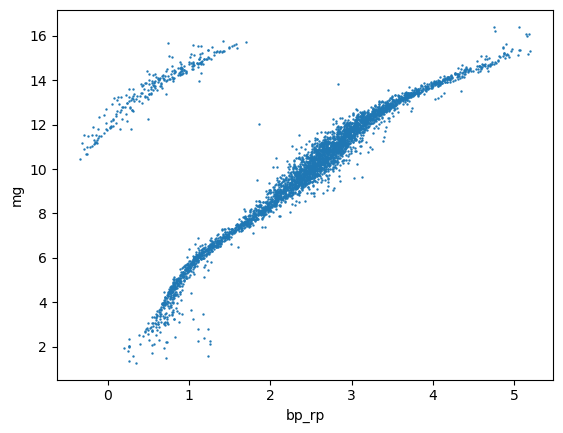

In [9]:
X=np.linspace(8, 16, 100)
plt.scatter(x,y,s=.5)
plt.ylabel('mg')
plt.xlabel('bp_rp');

In [6]:
#from outliers
def linear_model_double(x=None, y=None, σ=None):
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=100))#this should be the same for both groups
    
    # Main Sequence
    m_ms = numpyro.sample('m_ms', dist.Uniform(2, 5))
    b_ms = numpyro.sample('b_ms', dist.Uniform(0, 5))
    μ_ms = m_ms * x + b_ms
    dist_ms = dist.Normal(μ_ms, σ)

    # White Dwarfs
    m_wd = numpyro.sample('m_wd', dist.Uniform(2, 5))
    b_wd = numpyro.sample('b_wd', dist.Uniform(10, 15))
    μ_wd = m_wd * x + b_wd
    dist_wd = dist.Normal(μ_wd, σ)

    # We're going to assign each observation probabilistically to fg or bg using Categorical parameters
    P_ms = numpyro.sample('P_ms', dist.Uniform(0, 1)) # Prob an observation will be in the foreground

    # Define the foreground/background parameters, with equal probability between categories
    mixing_dist = dist.Categorical(probs=jnp.array([P_ms, 1 - P_ms]))
    mixture = dist.MixtureGeneral(mixing_dist, [dist_ms, dist_wd])

    # Likelihood
    with numpyro.plate("data", len(x)):
        y_ = numpyro.sample("obs", mixture, obs=y)

        # Until here, where we can track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        numpyro.deterministic(
            "log_p_ms", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

In [8]:
#from outliers
rng_key = random.PRNGKey(3)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model_double)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_ms      0.94      0.00      0.94      0.93      0.94   9758.82      1.00
      b_ms      2.59      0.03      2.59      2.54      2.63   5883.91      1.00
      b_wd     12.18      0.06     12.17     12.08     12.27   6346.91      1.00
      m_ms      2.94      0.01      2.94      2.92      2.95   5794.69      1.00
      m_wd      2.50      0.07      2.50      2.37      2.61   6308.51      1.00
   scatter      0.56      0.01      0.56      0.55      0.57  10606.35      1.00

Number of divergences: 0


In [ ]:
az.plot_trace(mcmc, var_names=['b_ms','b_wd','m_ms','m_wd','P_ms'])
plt.tight_layout()

In [9]:
samples = mcmc.get_samples()

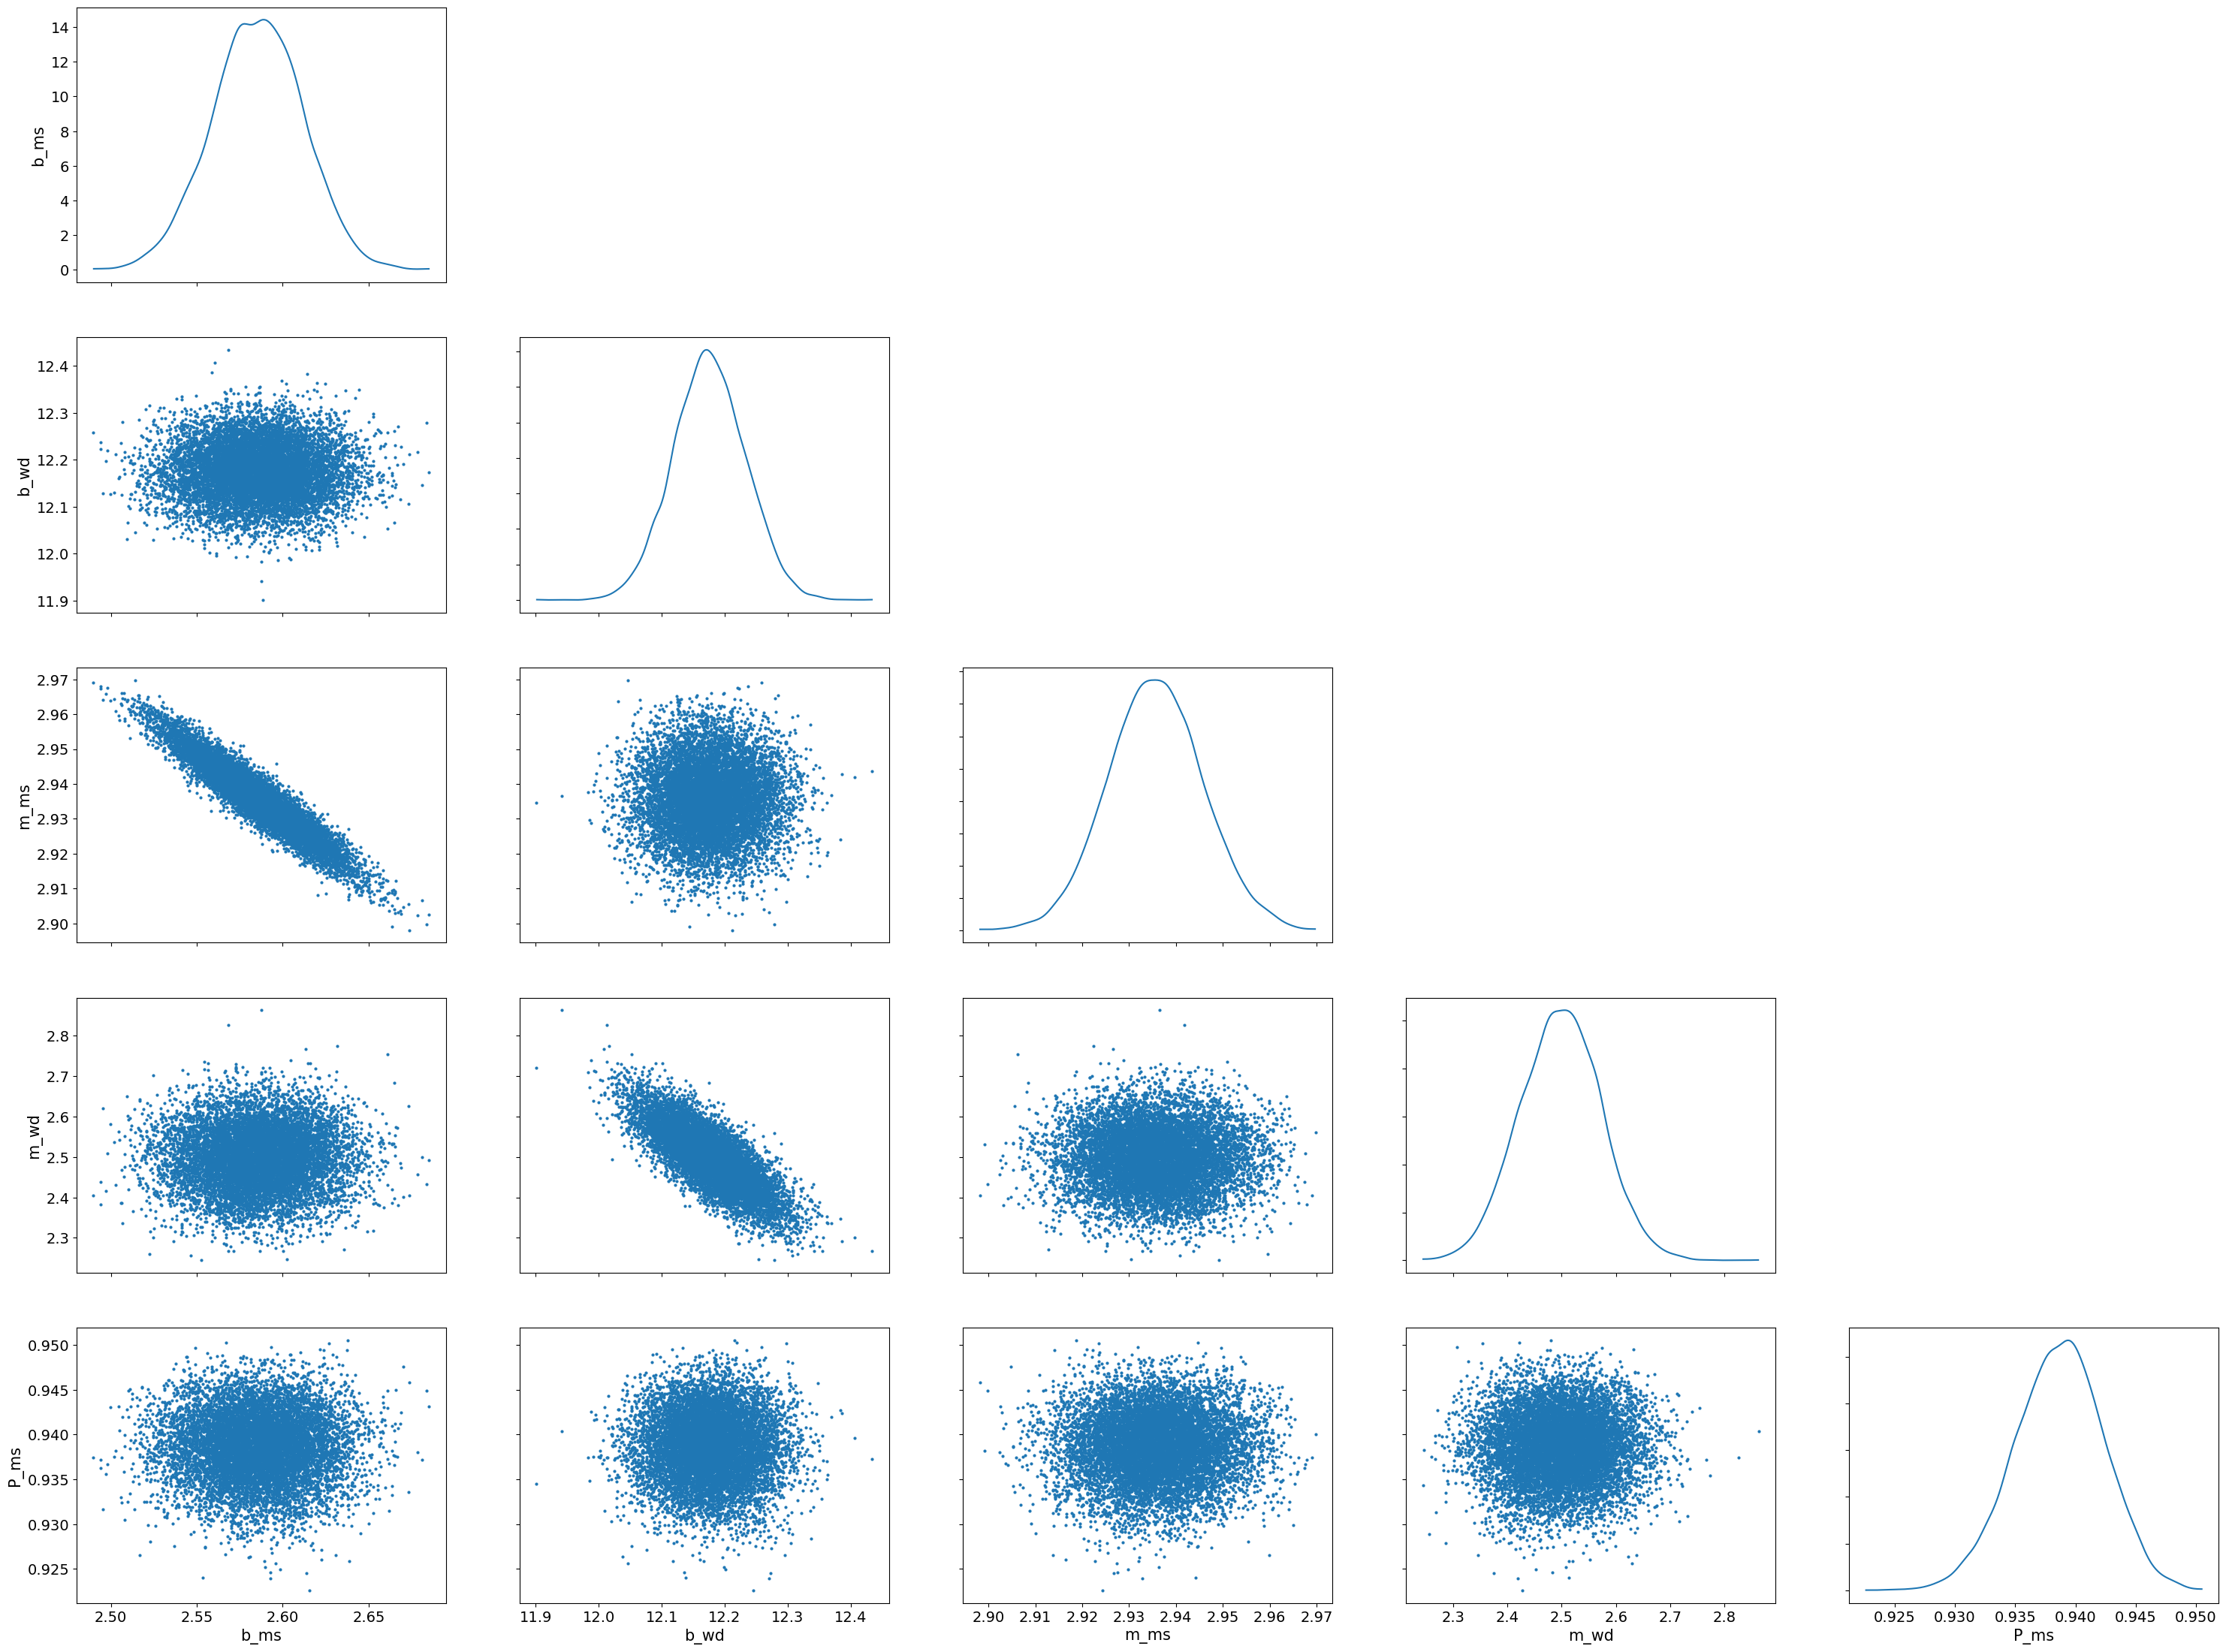

In [10]:
az.plot_pair(mcmc,var_names=['b_ms','b_wd','m_ms','m_wd','P_ms'], marginals=True);

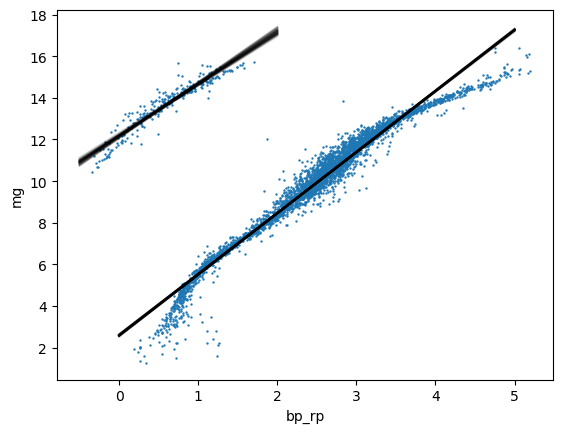

In [11]:
X1 = jnp.linspace(0, 5, 100)
X2 = jnp.linspace(-.5, 2, 100)
plt.scatter(x,y,s=.5)

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m_ms'][i] * X1 + samples['b_ms'][i]
    plt.plot(X1, mu, color='k', alpha=0.1);
    mu = samples['m_wd'][i] * X2 + samples['b_wd'][i]
    plt.plot(X2, mu, color='k', alpha=0.1);

plt.ylabel('mg')
plt.xlabel('bp_rp');

In [12]:
p_ms = jnp.exp(samples["log_p_ms"][..., 0])
np.shape(p_ms)

(10000, 4070)

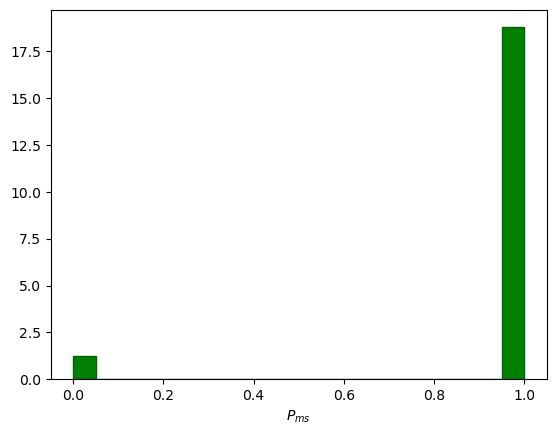

In [13]:
plt.hist(p_ms[1], label='$i=0$',bins=20,density=True,facecolor='green',edgecolor='darkgreen') # Plot for the first data point
plt.xlabel("$P_{ms}$");

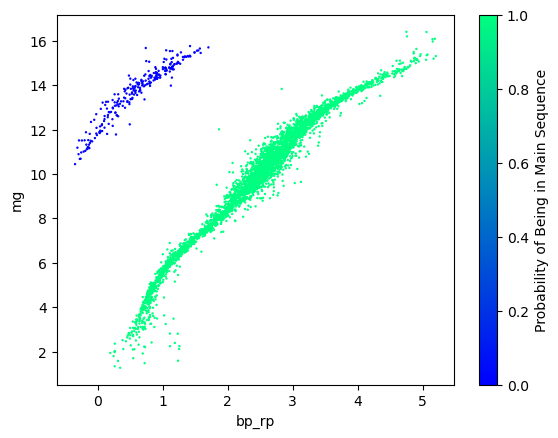

In [14]:
plt.scatter(x,y,s=.5,c=p_ms[1],cmap='winter')
plt.colorbar(label='Probability of Being in Main Sequence')
plt.ylabel('mg')
plt.xlabel('bp_rp');

## Relaxing the Priors

In [5]:
#from outliers
def linear_model_double2(x=None, y=None, σ=None):
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=100))#this should be the same for both groups
   
    # Main Sequence
    m_ms = numpyro.sample('m_ms', dist.Normal(scale=10))
    b_ms = numpyro.sample('b_ms', dist.Normal(scale=20))
    μ_ms = m_ms * x + b_ms
    dist_ms = dist.Normal(μ_ms, σ)

    # White Dwarfs
    m_wd = numpyro.sample('m_wd', dist.Normal(scale=10))
    b_wd = numpyro.sample('b_wd', dist.Normal(scale=20))
    μ_wd = m_wd * x + b_wd
    dist_wd = dist.Normal(μ_wd, σ)

    # We're going to assign each observation probabilistically to fg or bg using Categorical parameters
    P_ms = numpyro.sample('P_ms', dist.Uniform(0, 1)) # Prob an observation will be in the foreground

    # Define the foreground/background parameters, with equal probability between categories
    mixing_dist = dist.Categorical(probs=jnp.array([P_ms, 1 - P_ms]))
    mixture = dist.MixtureGeneral(mixing_dist, [dist_ms, dist_wd])

    # Likelihood
    with numpyro.plate("data", len(x)):
        y_ = numpyro.sample("obs", mixture, obs=y)

        # Until here, where we can track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        numpyro.deterministic(
            "log_p_ms", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

In [10]:
#from outliers
rng_key = random.PRNGKey(3)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model_double2)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_ms      0.51      0.43      0.51      0.08      0.94      1.00    118.04
      b_ms      7.96      5.38      7.94      2.54     13.39      1.00    173.24
      b_wd      7.28      4.90      7.22      2.33     12.24      1.00    120.74
      m_ms      1.66      1.28      1.68      0.36      2.95      1.00     83.75
      m_wd      2.76      0.27      2.88      2.43      3.06      1.02      5.83
   scatter      0.56      0.01      0.56      0.55      0.58      2.04      1.29

Number of divergences: 0


In [11]:
samples = mcmc.get_samples()

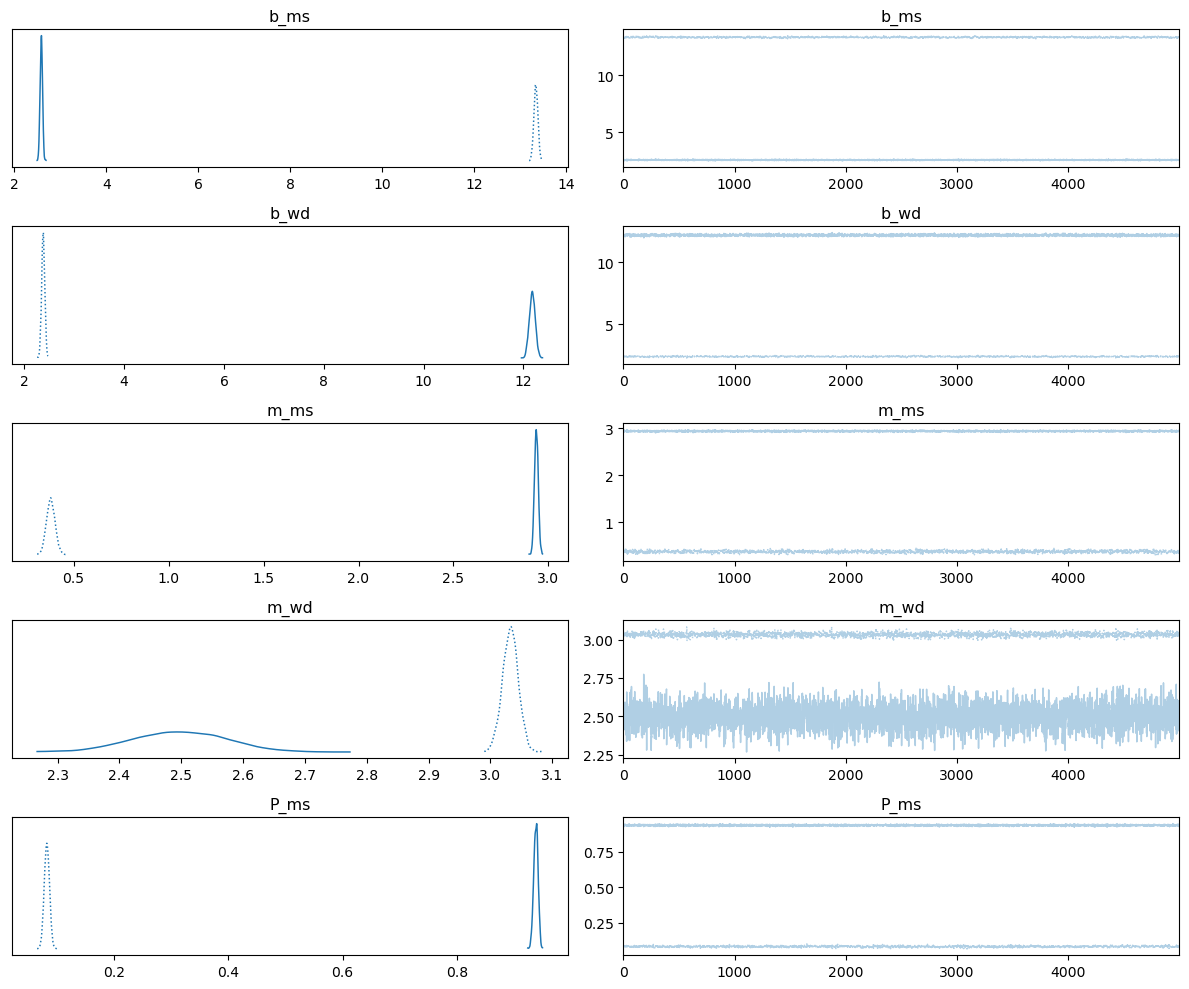

In [12]:
az.plot_trace(mcmc, var_names=['b_ms','b_wd','m_ms','m_wd','P_ms'])
plt.tight_layout()